## Individual Cell Distinction

The SegFormerSeg model produces **3-class** predictions:

| Pred class | Meaning |
|---|---|
| 0 | Background |
| 1 | Cytoplasm (both cells merged) |
| 2 | Nucleus (both cells merged) |

The raw ground-truth has **4 individual labels**:

| GT label | Cell | Region |
|---|---|---|
| 1 | Cell 1 | Cytoplasm |
| 2 | Cell 2 | Cytoplasm |
| 3 | Cell 1 | Nucleus |
| 4 | Cell 2 | Nucleus |

**Goal**: post-process the 3-class prediction to recover the 4-label distinction,  
then evaluate with IoU / Dice per class.

### Strategy
1. Run SegFormerSeg slice-by-slice → stack into a 3-D prediction volume.
2. Find the two nucleus connected components (3-D) → one per cell.
3. Use those nuclei as **seeds** to assign every cytoplasm voxel to one cell.
4. Compare the resulting 4-class volume with the GT.

### Methods compared
| Method | Description | Ideal for |
|---|---|---|
| **Barycenter** | Assign each cytoplasm voxel to the nearest nucleus 3-D centroid | Spherical nuclei |
| **Voronoi** | Assign to the nearest nucleus *voxel* (2× distance transforms) | Elongated / irregular nuclei |
| **Watershed** | Seed watershed from nucleus CCs on the combined cell region | Biologically curved boundaries |

In [ ]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import os, sys
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from tqdm import tqdm
from scipy.ndimage import (
    label            as nd_label,
    center_of_mass,
    distance_transform_edt,
    gaussian_filter1d,
)
from skimage.segmentation import watershed
from skimage.measure    import find_contours as skimage_find_contours
from scipy.signal       import find_peaks    as sp_find_peaks

OWLO_DIR  = r'C:\Users\marti\Desktop\Owlo-test'
UTILS_DIR = os.path.join(OWLO_DIR, 'utils')
if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

from models import SegFormerSeg
from train_functions import load_tif_stack, predict_slice

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

In [ ]:
# ── 1. Config & model ─────────────────────────────────────────────────────────
DATA_DIR = r'C:\Users\marti\Downloads\2025-11-19_Simu_twocells\2025-11-19_Simu_twocells'
CKPT_DIR = os.path.join(OWLO_DIR, 'model_weights')
IMG_SIZE  = (256, 256)   # SegFormerSeg training resolution

# Reproduce the exact train/val split used during training (seed=42, val_frac=0.15)
ALL_K = list(range(100))
rng   = np.random.default_rng(seed=42)
perm  = rng.permutation(ALL_K).tolist()
n_val = max(1, int(len(perm) * 0.15))
VAL_K = perm[:n_val]
print(f'Val volumes ({len(VAL_K)}): {sorted(VAL_K)}')

# Load SegFormerSeg
ckpt_path = os.path.join(CKPT_DIR, 'best_segformer.pth')
model     = SegFormerSeg(num_classes=3, freeze_encoder=True, variant='b1')
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model.to(DEVICE).eval()
n_tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'SegFormerSeg loaded: {n_tr:,} trainable params')

In [13]:
# ── 2. Helper functions ───────────────────────────────────────────────────────

def predict_volume_2d(model, img_vol, device, img_size):
    """Run 2-D model on every slice. Returns (N, h, w) int64 prediction."""
    preds = []
    with torch.no_grad():
        for s in range(img_vol.shape[0]):
            preds.append(predict_slice(model, img_vol[s], device, img_size=img_size))
    return np.stack(preds)


def load_raw_gt_volume(mask_path, img_size):
    """
    Load mask tif, decode the ×51 uint8 encoding, keep labels 0..4.

      0         = background (raw label 0 or 5)
      1 / 2     = cytoplasm of cell 1 / cell 2
      3 / 4     = nucleus   of cell 1 / cell 2

    Resizes each slice to img_size via nearest-neighbour so shapes
    match the SegFormerSeg predictions.
    """
    tif = load_tif_stack(mask_path)                                     # (N, H, W) uint8
    raw = np.round(tif.astype(np.float32) / 51).astype(np.int32)       # 0..5
    raw = np.where(np.isin(raw, [1, 2, 3, 4]), raw, 0).astype(np.int32)
    if raw.shape[1:] != tuple(img_size):
        t   = torch.from_numpy(raw).unsqueeze(1).float()                # (N, 1, H, W)
        t   = F.interpolate(t, size=img_size, mode='nearest')
        raw = t.squeeze(1).long().numpy()
    return raw.astype(np.int32)


def get_top2_nucleus_ccs(pred_vol):
    """
    Label 3-D connected components of nucleus class (label 2).
    Keeps the 2 largest; returns (cc_vol, n_found).
      cc_vol  : values in {0, 1, 2}
      n_found : how many CCs were found (< 2 means method will be skipped)
    """
    nuc_mask   = (pred_vol == 2)
    cc_full, n = nd_label(nuc_mask)
    if n == 0:
        return np.zeros_like(pred_vol, dtype=np.int32), 0
    sizes   = [(cc_full == i).sum() for i in range(1, n + 1)]
    top_ids = np.argsort(sizes)[::-1][:2] + 1          # 1-indexed CC ids
    cc_vol  = np.zeros_like(pred_vol, dtype=np.int32)
    for new_id, old_id in enumerate(top_ids, start=1):
        cc_vol[cc_full == old_id] = new_id
    return cc_vol, min(n, 2)


def match_cells(cc_vol, gt_raw):
    """
    Decide which nucleus CC (1 or 2) is cell 1 (GT nucleus label 3)
    vs cell 2 (GT nucleus label 4).
    Tests both assignments, picks better nucleus IoU sum.
    Returns {cc_id: cell_id} mapping.
    """
    def iou_bin(a, b):
        i, u = int((a & b).sum()), int((a | b).sum())
        return i / (u + 1e-8)

    cc1, cc2 = (cc_vol == 1), (cc_vol == 2)
    gn1, gn2 = (gt_raw == 3), (gt_raw == 4)
    score_A  = iou_bin(cc1, gn1) + iou_bin(cc2, gn2)   # cc1→cell1, cc2→cell2
    score_B  = iou_bin(cc1, gn2) + iou_bin(cc2, gn1)   # cc1→cell2, cc2→cell1
    return {1: 1, 2: 2} if score_A >= score_B else {1: 2, 2: 1}


def build_4class(cyto_asgn, cc_vol, cell_mapping):
    """
    Build 4-class volume:
      0 = background
      1 = cell 1 cytoplasm   (matches GT label 1)
      2 = cell 2 cytoplasm   (matches GT label 2)
      3 = cell 1 nucleus     (matches GT label 3)
      4 = cell 2 nucleus     (matches GT label 4)
    """
    result = np.zeros_like(cc_vol, dtype=np.int32)
    for cc_id, cell_id in cell_mapping.items():
        result[cc_vol == cc_id]    = cell_id + 2   # nucleus  → 3 or 4
        result[cyto_asgn == cc_id] = cell_id        # cytoplasm → 1 or 2
    return result


def compute_4class_metrics(pred_4c, gt_4c):
    """
    Compute per-class IoU + Dice for labels 1..4 and their mean.
    Returns {label_name: {'IoU': float, 'Dice': float}, 'mean': {...}}.
    """
    labels = {1: 'Cell1-cyto', 2: 'Cell2-cyto', 3: 'Cell1-nuc', 4: 'Cell2-nuc'}
    out    = {}
    for lbl, name in labels.items():
        p, g  = (pred_4c == lbl), (gt_4c == lbl)
        inter = int((p & g).sum()); union = int((p | g).sum())
        denom = int(p.sum()) + int(g.sum())
        out[name] = {
            'IoU' : inter / (union + 1e-8),
            'Dice': 2 * inter / (denom + 1e-8),
        }
    out['mean'] = {
        'IoU' : float(np.mean([v['IoU']  for v in out.values()])),
        'Dice': float(np.mean([v['Dice'] for v in out.values()])),
    }
    return out


print('Helper functions defined.')

Helper functions defined.


---
## Methods

### Method 1 — Barycenter
Compute the 3-D **centroid** of each nucleus CC. Each cytoplasm voxel is assigned to the cell whose centroid is nearest.

*Pros*: very fast, intuitive. *Cons*: inaccurate for elongated / non-spherical nuclei.

---

### Method 2 — Voronoi (nearest-nucleus-voxel)
Two distance transforms (one per nucleus CC). Each cytoplasm voxel goes to the cell whose nucleus voxels are nearest.

*Pros*: exact nearest-voxel assignment; handles elongated nuclei. *Cons*: two full-volume distance transforms (still fast).

---

### Method 3 — Watershed
Nucleus CCs as seeds; watershed on the negative distance transform of the combined cell region. Standard in bio-image analysis (Meyer 1994).

*Pros*: natural-looking, topology-aware boundaries. *Cons*: slightly slower.

---

### Method 4 — Contour-cut *(new — 2D, slice-by-slice)*
**Key observation:** when two cells touch, their combined boundary is smooth everywhere *except* at exactly **two contact points**, which appear as sharp concavities.

Algorithm per slice:
1. Compute the ordered boundary contour of the combined cell mask (cytoplasm ∪ nucleus).
2. Smooth the contour circularly (Gaussian, σ = 3 px) to suppress pixelation noise.
3. Compute signed curvature κ along the smoothed contour.
4. Find the **2 most-concave (most-negative κ) points** that are ≥ ¼ contour-length apart — these are the contact points.
5. Draw a straight cut line through them; assign each cytoplasm side to the nearest nucleus centroid.

*Special cases handled:*
- **Cells already separate in 2D** (≥ 2 CCs): assign each CC to the nearest nucleus directly — no cut needed.
- **Contact points not found** (e.g. very wide flat contact): fall back to per-slice Voronoi.

*Pros*: purely geometric, no 3D needed, naturally finds the true physical contact boundary.
*Cons*: relies on the boundary being smooth except at contact; may miss subtle concavities.

---

In [14]:
# ── Method 4: Contour-cut helpers ────────────────────────────────────────────

def find_contact_points_2d(combined_mask, smooth_sigma=3, min_sep_frac=0.2):
    """
    Find the two 'spiky' contact points on the boundary of the combined cell mask.

    The boundary of two touching cells is smooth everywhere except at the two
    contact points, which appear as sharp concavities (negative curvature peaks).

    Returns ((r1,c1), (r2,c2)) as float coordinates, or None if not found.
    """
    contours = skimage_find_contours(combined_mask.astype(float), 0.5)
    if not contours:
        return None
    contour = max(contours, key=len)   # (N, 2) in (row, col) order
    n = len(contour)
    if n < 30:
        return None

    # Smooth the contour circularly to suppress pixelation noise
    y = gaussian_filter1d(contour[:, 0], sigma=smooth_sigma, mode='wrap')
    x = gaussian_filter1d(contour[:, 1], sigma=smooth_sigma, mode='wrap')

    # Signed curvature: κ = (x' y'' - y' x'') / (x'^2 + y'^2)^(3/2)
    # For a CCW contour, negative κ = concave from outside = contact point
    dy, dx   = np.gradient(y), np.gradient(x)
    d2y, d2x = np.gradient(dy), np.gradient(dx)
    kappa    = (dx * d2y - dy * d2x) / (dx**2 + dy**2 + 1e-8)**1.5

    # Find 2 well-separated local minima (most concave)
    min_dist  = max(int(n * min_sep_frac), 5)
    neg_peaks, _ = sp_find_peaks(-kappa, distance=min_dist)

    if len(neg_peaks) < 2:
        # Fallback: try with |κ| peaks (catches both convex and concave corners)
        neg_peaks, _ = sp_find_peaks(np.abs(kappa), distance=min_dist)
        if len(neg_peaks) < 2:
            return None
        order = np.argsort(np.abs(kappa[neg_peaks]))[::-1]
    else:
        order = np.argsort(kappa[neg_peaks])  # most negative first

    top2 = neg_peaks[order[:2]]
    return (y[top2[0]], x[top2[0]]), (y[top2[1]], x[top2[1]])


def split_mask_by_line(mask, p1, p2):
    """
    Split a binary mask into two halves by the infinite line through p1 and p2.
    Uses the sign of the 2-D cross-product (p2-p1) × (pt-p1).
    Returns (side_A, side_B) as boolean arrays.
    """
    r, c   = np.mgrid[:mask.shape[0], :mask.shape[1]]
    dr, dc = p2[0] - p1[0], p2[1] - p1[1]
    cross  = dr * (c - p1[1]) - dc * (r - p1[0])
    return (cross >= 0) & mask, (cross < 0) & mask


def method_contour_cut(pred_vol, gt_raw=None):
    """
    Method 4 — Contour-cut (2D, slice-by-slice).

    For each slice:
      - If the combined cell region is ALREADY two separate 2-D CCs:
          assign each CC to the nearest nucleus centroid (no cut needed).
      - Else (cells touching — one combined CC):
          1. Extract the ordered boundary contour.
          2. Smooth it circularly (σ=3 px).
          3. Compute curvature κ.
          4. Find the 2 most-concave points (contact points).
          5. Draw a straight line through them; assign each side to the
             nearest nucleus 3-D centroid (projected to 2-D).
      - Fallback if contact points not found: per-slice Voronoi distance.

    Nuclei (pred class 2) are labelled via the same 3-D CC logic as other methods.
    """
    cc_vol, n_found = get_top2_nucleus_ccs(pred_vol)
    if n_found < 2:
        return None, cc_vol, n_found

    N, H, W   = pred_vol.shape
    cyto_asgn = np.zeros((N, H, W), dtype=np.int32)

    # 3-D centroids of the two nucleus CCs → project to (y, x) for 2-D assignment
    cents_3d = center_of_mass((cc_vol > 0), cc_vol, [1, 2])  # list of (z, y, x)
    c1_2d    = np.array([cents_3d[0][1], cents_3d[0][2]])
    c2_2d    = np.array([cents_3d[1][1], cents_3d[1][2]])

    def nearest_cell(region_mask):
        """Return CC id (1 or 2) whose projected centroid is nearest to this region."""
        if not region_mask.any():
            return 1
        rc = np.array(center_of_mass(region_mask))  # (row, col)
        return 1 if np.linalg.norm(rc - c1_2d) <= np.linalg.norm(rc - c2_2d) else 2

    for s in range(N):
        cyto_s     = (pred_vol[s] == 1)
        combined_s = (pred_vol[s] > 0)    # cytoplasm + nucleus
        nuc_s      = cc_vol[s]             # nucleus CC labels in this slice

        if not cyto_s.any():
            continue

        # ── Case A: already 2 separate 2-D components ─────────────────────────
        _, n_comp = nd_label(combined_s)
        if n_comp >= 2:
            comp_lbl, n_cyto_comp = nd_label(cyto_s)
            for cid in range(1, n_cyto_comp + 1):
                comp_m = (comp_lbl == cid)
                cyto_asgn[s][comp_m] = nearest_cell(comp_m)

        # ── Case B: cells touching → try the curvature cut ────────────────────
        else:
            pts = find_contact_points_2d(combined_s)
            if pts is not None:
                p1, p2   = pts
                side_a, side_b = split_mask_by_line(cyto_s, p1, p2)
                cc_a     = nearest_cell(side_a)
                cc_b     = 2 if cc_a == 1 else 1
                cyto_asgn[s][side_a] = cc_a
                cyto_asgn[s][side_b] = cc_b
            else:
                # ── Fallback: per-slice Voronoi ────────────────────────────────
                if (nuc_s > 0).any():
                    dist1 = distance_transform_edt(nuc_s != 1)
                    dist2 = distance_transform_edt(nuc_s != 2)
                    cyto_asgn[s][cyto_s] = np.where(
                        dist1[cyto_s] <= dist2[cyto_s], 1, 2)
                else:
                    coords_yx = np.argwhere(cyto_s)
                    d1 = np.linalg.norm(coords_yx - c1_2d, axis=1)
                    d2 = np.linalg.norm(coords_yx - c2_2d, axis=1)
                    cyto_asgn[s][cyto_s] = np.where(d1 <= d2, 1, 2)

    return cyto_asgn, cc_vol, n_found


print('ContourCut helpers and method defined.')


ContourCut helpers and method defined.


In [23]:
# ── 3. Method implementations (Barycenter / Voronoi / Watershed / Oracle) ─────

def method_barycenter(pred_vol, gt_raw=None):
    """Assign cytoplasm to nearest nucleus 3-D centroid."""
    cc_vol, n_found = get_top2_nucleus_ccs(pred_vol)
    if n_found < 2:
        return None, cc_vol, n_found

    centroids   = center_of_mass((cc_vol > 0), cc_vol, [1, 2])  # [(z,y,x), (z,y,x)]
    cyto_mask   = (pred_vol == 1)
    cyto_coords = np.argwhere(cyto_mask)                         # (M, 3)
    cyto_asgn   = np.zeros_like(pred_vol, dtype=np.int32)
    if cyto_coords.size > 0:
        c0 = np.array(centroids[0]); c1 = np.array(centroids[1])
        d0 = np.linalg.norm(cyto_coords - c0, axis=1)
        d1 = np.linalg.norm(cyto_coords - c1, axis=1)
        cyto_asgn[cyto_mask] = np.where(d0 <= d1, 1, 2)
    return cyto_asgn, cc_vol, n_found


def method_voronoi(pred_vol, gt_raw=None):
    """Assign cytoplasm to nearest nucleus voxel (Voronoi partition)."""
    cc_vol, n_found = get_top2_nucleus_ccs(pred_vol)
    if n_found < 2:
        return None, cc_vol, n_found

    cell_mask  = (pred_vol > 0)
    dist1      = distance_transform_edt(cc_vol != 1)
    dist2      = distance_transform_edt(cc_vol != 2)
    assignment = np.where(dist1 <= dist2, 1, 2).astype(np.int32)
    assignment[~cell_mask] = 0
    cyto_asgn  = np.zeros_like(pred_vol, dtype=np.int32)
    cyto_asgn[pred_vol == 1] = assignment[pred_vol == 1]
    return cyto_asgn, cc_vol, n_found


def method_watershed(pred_vol, gt_raw=None):
    """Watershed seeded from nucleus CCs on the combined cell region."""
    cc_vol, n_found = get_top2_nucleus_ccs(pred_vol)
    if n_found < 2:
        return None, cc_vol, n_found

    cell_mask = (pred_vol > 0)
    dist      = distance_transform_edt(cell_mask)
    ws        = watershed(-dist, markers=cc_vol, mask=cell_mask)
    cyto_asgn = np.zeros_like(pred_vol, dtype=np.int32)
    cyto_asgn[pred_vol == 1] = ws[pred_vol == 1]
    return cyto_asgn, cc_vol, n_found


def method_oracle(pred_vol, gt_raw):
    """Oracle upper bound: use GT nucleus labels as perfect seeds, then Voronoi."""
    if gt_raw is None:
        raise ValueError('Oracle requires gt_raw.')
    cc_vol = np.zeros_like(pred_vol, dtype=np.int32)
    cc_vol[gt_raw == 3] = 1
    cc_vol[gt_raw == 4] = 2
    n_found = int((cc_vol == 1).any()) + int((cc_vol == 2).any())
    if n_found < 2:
        return None, cc_vol, n_found

    cell_mask  = (pred_vol > 0)
    dist1      = distance_transform_edt(cc_vol != 1)
    dist2      = distance_transform_edt(cc_vol != 2)
    assignment = np.where(dist1 <= dist2, 1, 2).astype(np.int32)
    assignment[~cell_mask] = 0
    cyto_asgn  = np.zeros_like(pred_vol, dtype=np.int32)
    cyto_asgn[pred_vol == 1] = assignment[pred_vol == 1]
    return cyto_asgn, cc_vol, n_found



METHODS = {
    'Barycenter' : method_barycenter,
    'Voronoi'    : method_voronoi,
    'Watershed'  : method_watershed,
    'ContourCut' : method_contour_cut,
}
print('Methods defined:', list(METHODS))


Methods defined: ['Barycenter', 'Voronoi', 'Watershed', 'ContourCut']


In [24]:
# ── 4. Run all methods on the validation set ──────────────────────────────────
# For each volume:
#   a) predict all slices with SegFormerSeg (stride=1 for proper 3D volumes)
#   b) load raw GT (labels 1..4)
#   c) apply each method to get a 4-class prediction
#   d) match cell identities to GT, then compute metrics

VOLUME_RESULTS = {}                       # k → {method: pred_4c, 'gt_4c', 'pred_3c'}
METHOD_METRICS = {m: [] for m in METHODS} # method → list of per-volume metric dicts
SKIP_COUNTS    = {m: 0  for m in METHODS}

for k in tqdm(VAL_K, desc='Volumes'):
    img_vol = load_tif_stack(
        os.path.join(DATA_DIR, f'vol_linear_{k}.tif')).astype(np.float32) / 255.0
    gt_4c   = load_raw_gt_volume(
        os.path.join(DATA_DIR, f'mask_{k}.tif'), IMG_SIZE)   # (N, 256, 256) labels 0..4
    pred_3c = predict_volume_2d(model, img_vol, DEVICE, IMG_SIZE)  # (N, 256, 256) 0/1/2

    vol_entry = {'gt_4c': gt_4c, 'pred_3c': pred_3c}

    for mname, mfn in METHODS.items():
        cyto_asgn, cc_vol, n_found = mfn(pred_3c, gt_raw=gt_4c)
        if n_found < 2:
            SKIP_COUNTS[mname] += 1
            vol_entry[mname]    = None
            continue

        # Oracle has a fixed cell→CC mapping; others need the IoU-based matcher
        cell_map = {1: 1, 2: 2} if mname == 'Oracle' else match_cells(cc_vol, gt_4c)
        pred_4c  = build_4class(cyto_asgn, cc_vol, cell_map)
        METHOD_METRICS[mname].append(compute_4class_metrics(pred_4c, gt_4c))
        vol_entry[mname] = pred_4c

    VOLUME_RESULTS[k] = vol_entry

print('\nEvaluation complete.')
for m in METHODS:
    n = len(METHOD_METRICS[m])
    print(f'  {m:<14}: {n:>2} vol evaluated, {SKIP_COUNTS[m]} skipped (< 2 nucleus CCs found)')

Volumes: 100%|██████████| 15/15 [05:30<00:00, 22.03s/it]


Evaluation complete.
  Barycenter    : 15 vol evaluated, 0 skipped (< 2 nucleus CCs found)
  Voronoi       : 15 vol evaluated, 0 skipped (< 2 nucleus CCs found)
  Watershed     : 15 vol evaluated, 0 skipped (< 2 nucleus CCs found)
  ContourCut    : 15 vol evaluated, 0 skipped (< 2 nucleus CCs found)


In [25]:
# ── 5. Metrics summary tables ─────────────────────────────────────────────────
CLASS_NAMES = ['Cell1-cyto', 'Cell2-cyto', 'Cell1-nuc', 'Cell2-nuc', 'mean']

for metric in ('IoU', 'Dice'):
    print(f'\n{metric}:')
    print(f'{"Method":<14}', ' '.join(f'{n:>12}' for n in CLASS_NAMES))
    print('─' * (14 + 13 * len(CLASS_NAMES)))
    for mname, vol_list in METHOD_METRICS.items():
        if not vol_list:
            print(f'{mname:<14}  (no data — all volumes skipped)'); continue
        row = ' '.join(
            f'{np.mean([v[cn][metric] for v in vol_list if cn in v]):12.4f}'
            for cn in CLASS_NAMES
        )
        print(f'{mname:<14}  {row}')


IoU:
Method           Cell1-cyto   Cell2-cyto    Cell1-nuc    Cell2-nuc         mean
───────────────────────────────────────────────────────────────────────────────
Barycenter            0.9310       0.9395       0.8822       0.8705       0.9058
Voronoi               0.9313       0.9395       0.8822       0.8705       0.9059
Watershed             0.9462       0.9535       0.8822       0.8705       0.9131
ContourCut            0.9593       0.9645       0.8822       0.8705       0.9191

Dice:
Method           Cell1-cyto   Cell2-cyto    Cell1-nuc    Cell2-nuc         mean
───────────────────────────────────────────────────────────────────────────────
Barycenter            0.9640       0.9686       0.9372       0.9300       0.9499
Voronoi               0.9642       0.9687       0.9372       0.9300       0.9500
Watershed             0.9722       0.9761       0.9372       0.9300       0.9539
ContourCut            0.9792       0.9819       0.9372       0.9300       0.9570


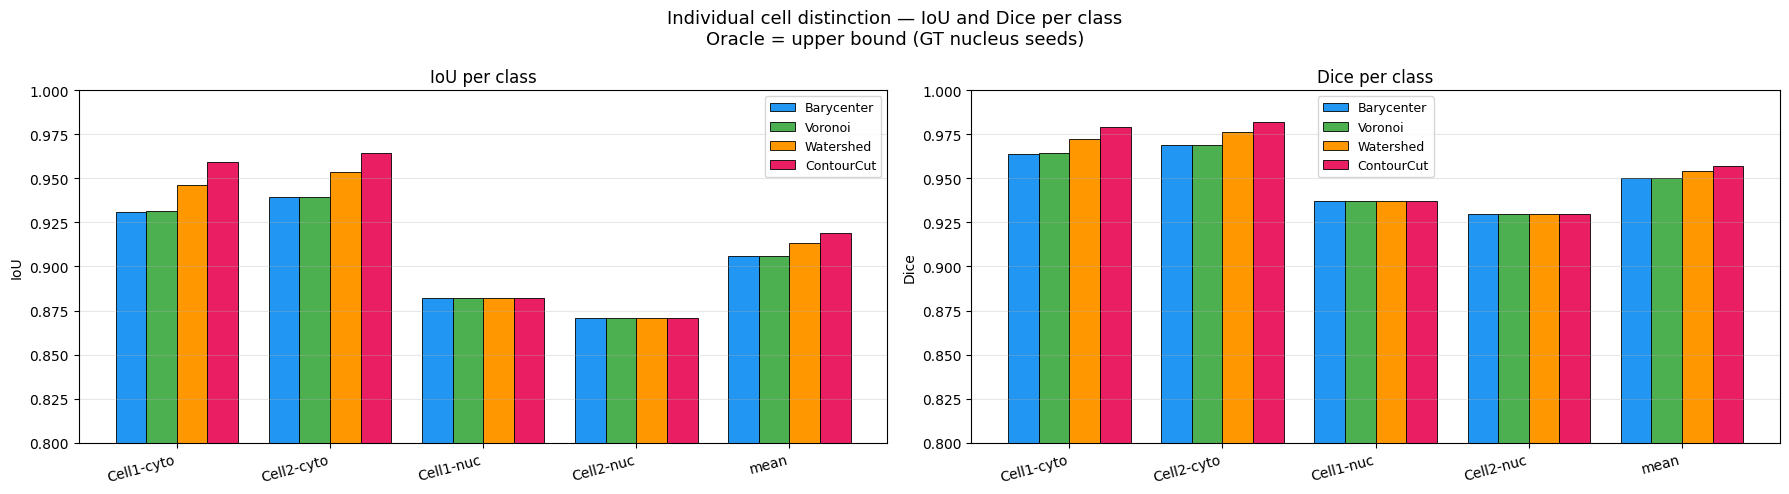

In [35]:
# ── 6. Bar-chart comparison ───────────────────────────────────────────────────
METHOD_COLORS = {
    'Barycenter' : '#2196F3',
    'Voronoi'    : '#4CAF50',
    'Watershed'  : '#FF9800',
    'ContourCut' : '#E91E63',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
bar_w = 0.8 / len(METHODS)

for ax_idx, metric in enumerate(('IoU', 'Dice')):
    ax = axes[ax_idx]
    x  = np.arange(len(CLASS_NAMES))
    for i, (mname, vol_list) in enumerate(METHOD_METRICS.items()):
        if not vol_list:
            continue
        vals = [
            np.mean([v[cn][metric] for v in vol_list if cn in v])
            for cn in CLASS_NAMES
        ]
        ax.bar(
            x + i * bar_w - 0.4 + bar_w / 2, vals, bar_w,
            label=mname, color=METHOD_COLORS.get(mname, 'grey'),
            edgecolor='k', linewidth=0.6,
        )
    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
    ax.set_ylim(0.8, 1.); ax.set_ylabel(metric)
    ax.set_title(f'{metric} per class')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Individual cell distinction — IoU and Dice per class\n'
             'Oracle = upper bound (GT nucleus seeds)', fontsize=13)
plt.tight_layout()
plt.show()


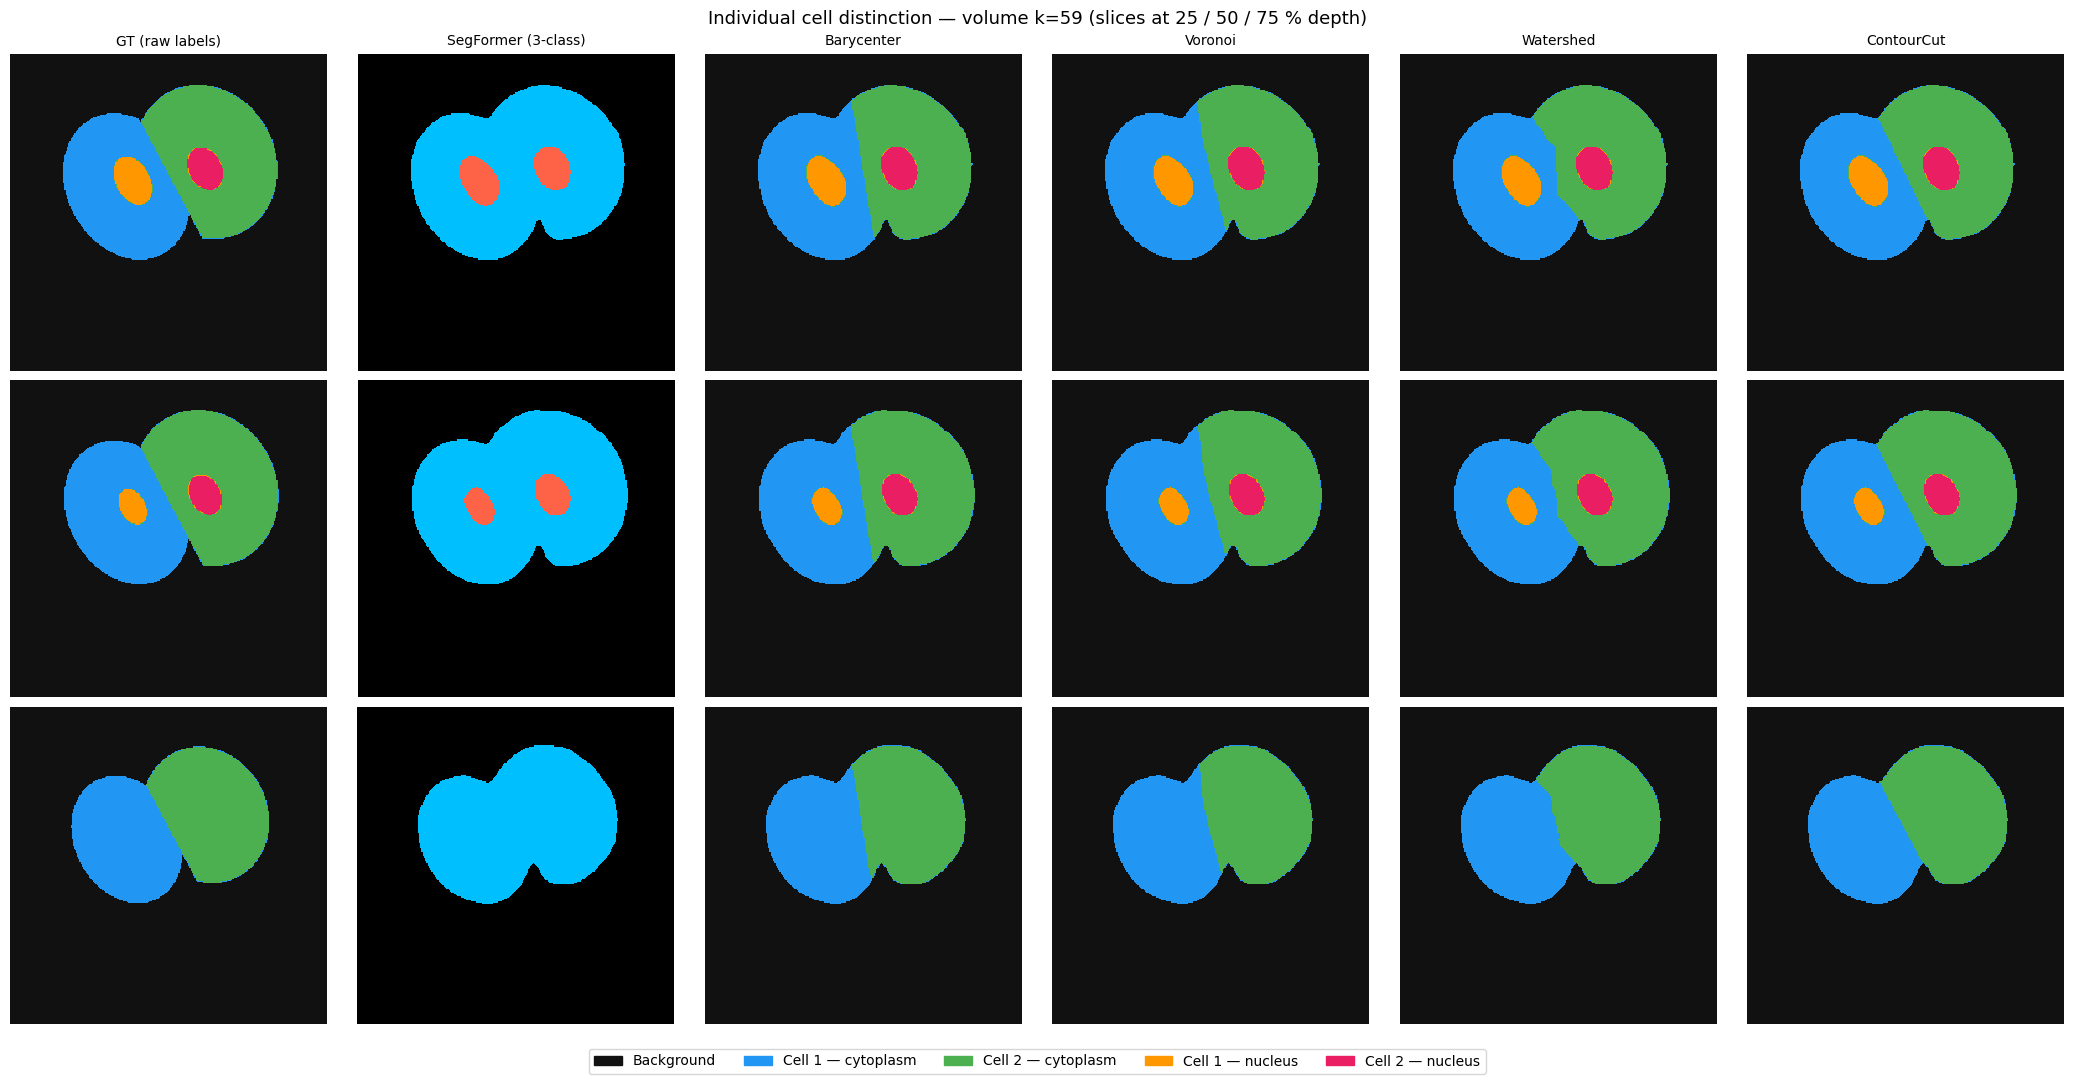

In [27]:
# ── 7. Visual comparison — one volume, 3 depth positions ─────────────────────
CMAP5 = mcolors.ListedColormap(['#111111', '#2196F3', '#4CAF50', '#FF9800', '#E91E63'])
# 0=bg, 1=cell1-cyto(blue), 2=cell2-cyto(green), 3=cell1-nuc(orange), 4=cell2-nuc(pink)
norm5 = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], CMAP5.N)
CMAP3 = mcolors.ListedColormap(['black', 'deepskyblue', 'tomato'])
norm3 = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], CMAP3.N)

k_vis    = VAL_K[0]
res_vis  = VOLUME_RESULTS[k_vis]
gt_4c_v  = res_vis['gt_4c']
pred_3c  = res_vis['pred_3c']
n_sl     = gt_4c_v.shape[0]

# Show three representative slices
slice_idx  = [n_sl // 4, n_sl // 2, 3 * n_sl // 4]
col_titles = ['GT (raw labels)', 'SegFormer (3-class)'] + list(METHODS)
n_rows, n_cols = len(slice_idx), len(col_titles)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows))

for row, s in enumerate(slice_idx):
    axes[row, 0].imshow(gt_4c_v[s],  cmap=CMAP5, norm=norm5)
    axes[row, 0].set_ylabel(f'slice {s}', fontsize=10)
    axes[row, 1].imshow(pred_3c[s],  cmap=CMAP3, norm=norm3)
    for col, mname in enumerate(METHODS, start=2):
        pred_4c = res_vis.get(mname)
        if pred_4c is None:
            axes[row, col].text(0.5, 0.5, 'N/A (skipped)',
                                ha='center', va='center',
                                transform=axes[row, col].transAxes, fontsize=11)
        else:
            axes[row, col].imshow(pred_4c[s], cmap=CMAP5, norm=norm5)
    for ax in axes[row]:
        ax.axis('off')

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10)

patches = [
    mpatches.Patch(color='#111111', label='Background'),
    mpatches.Patch(color='#2196F3', label='Cell 1 — cytoplasm'),
    mpatches.Patch(color='#4CAF50', label='Cell 2 — cytoplasm'),
    mpatches.Patch(color='#FF9800', label='Cell 1 — nucleus'),
    mpatches.Patch(color='#E91E63', label='Cell 2 — nucleus'),
]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle(f'Individual cell distinction — volume k={k_vis} '
             f'(slices at 25 / 50 / 75 % depth)', fontsize=13)
plt.tight_layout()
plt.show()

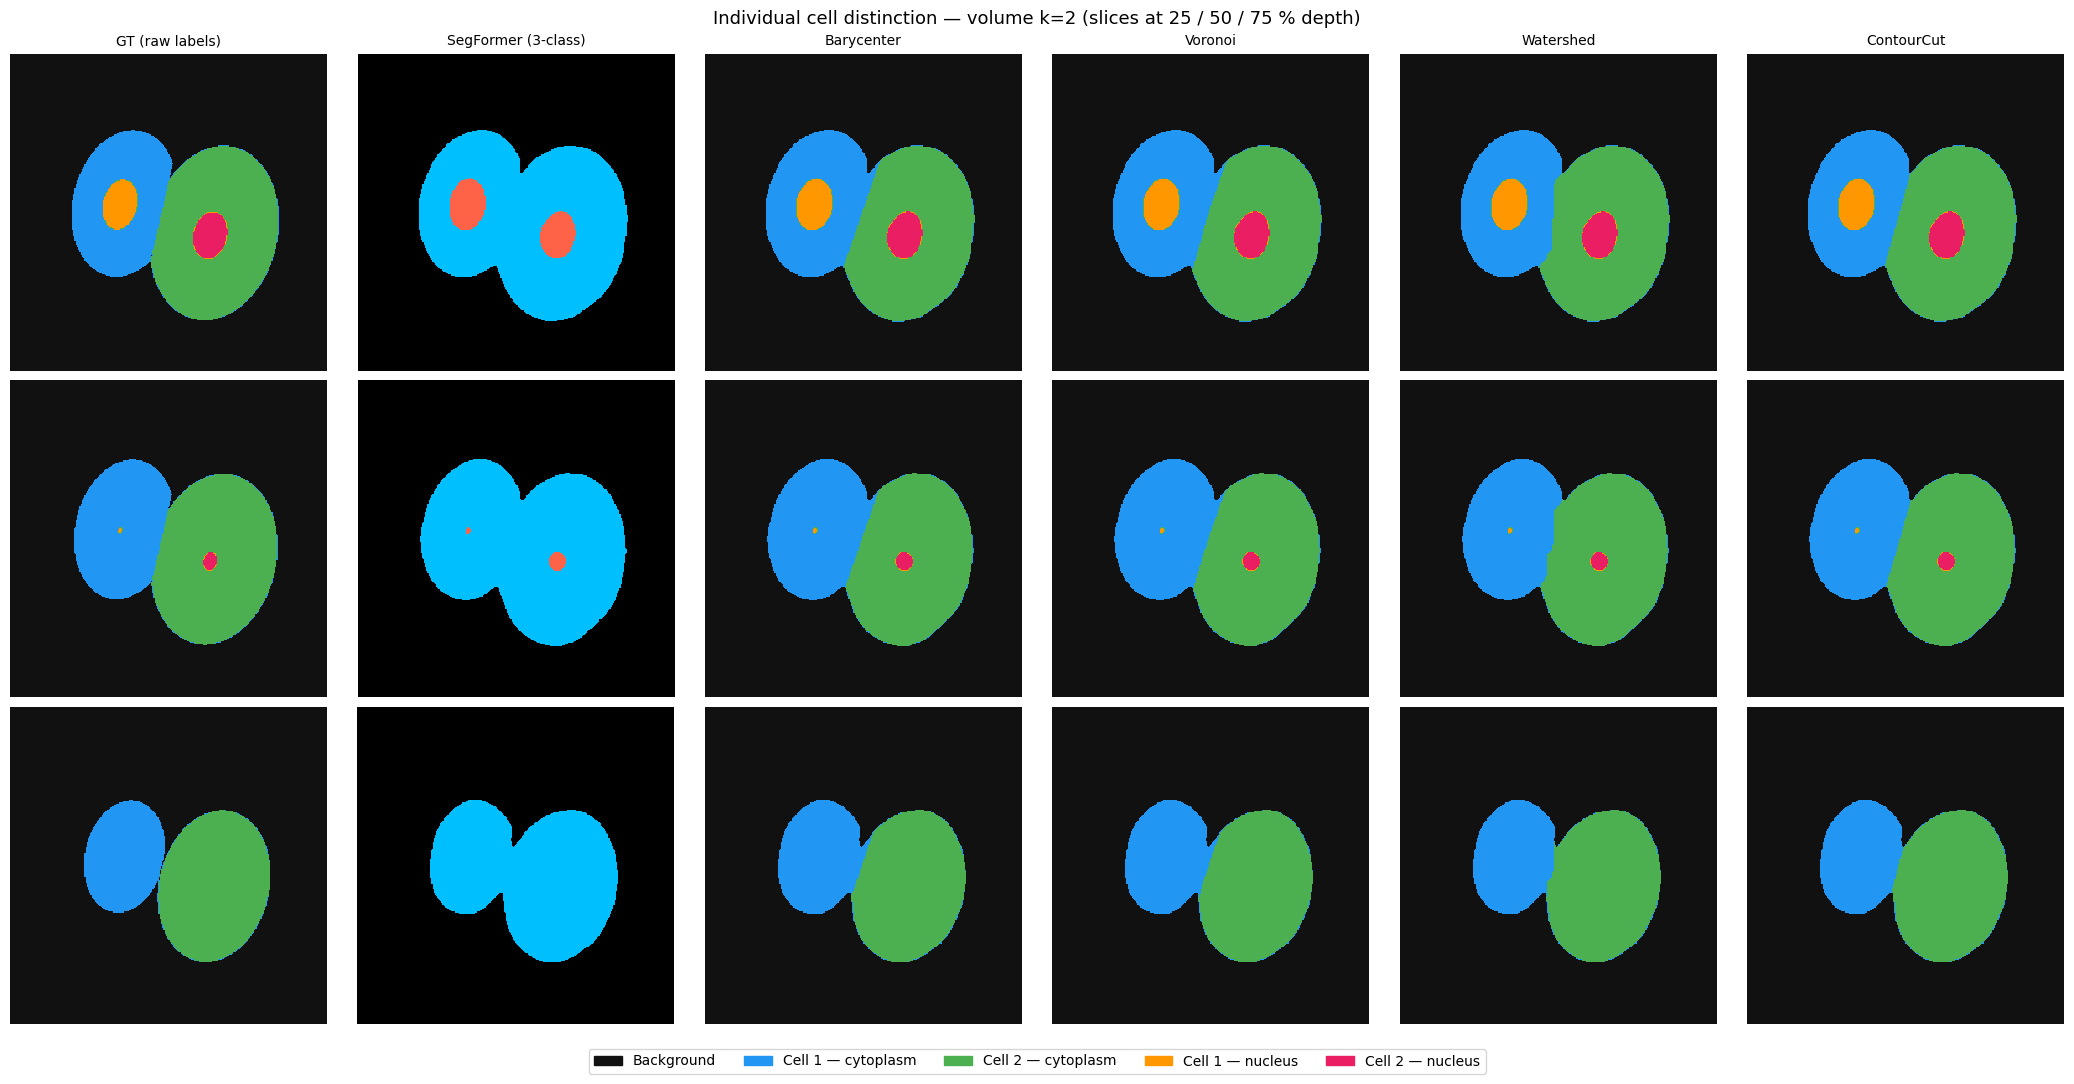

In [30]:
# ── 7. Visual comparison — one volume, 3 depth positions ─────────────────────
CMAP5 = mcolors.ListedColormap(['#111111', '#2196F3', '#4CAF50', '#FF9800', '#E91E63'])
# 0=bg, 1=cell1-cyto(blue), 2=cell2-cyto(green), 3=cell1-nuc(orange), 4=cell2-nuc(pink)
norm5 = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], CMAP5.N)
CMAP3 = mcolors.ListedColormap(['black', 'deepskyblue', 'tomato'])
norm3 = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], CMAP3.N)

k_vis    = VAL_K[10]
res_vis  = VOLUME_RESULTS[k_vis]
gt_4c_v  = res_vis['gt_4c']
pred_3c  = res_vis['pred_3c']
n_sl     = gt_4c_v.shape[0]

# Show three representative slices
slice_idx  = [n_sl // 4, n_sl // 2, 3 * n_sl // 4]
col_titles = ['GT (raw labels)', 'SegFormer (3-class)'] + list(METHODS)
n_rows, n_cols = len(slice_idx), len(col_titles)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows))

for row, s in enumerate(slice_idx):
    axes[row, 0].imshow(gt_4c_v[s],  cmap=CMAP5, norm=norm5)
    axes[row, 0].set_ylabel(f'slice {s}', fontsize=10)
    axes[row, 1].imshow(pred_3c[s],  cmap=CMAP3, norm=norm3)
    for col, mname in enumerate(METHODS, start=2):
        pred_4c = res_vis.get(mname)
        if pred_4c is None:
            axes[row, col].text(0.5, 0.5, 'N/A (skipped)',
                                ha='center', va='center',
                                transform=axes[row, col].transAxes, fontsize=11)
        else:
            axes[row, col].imshow(pred_4c[s], cmap=CMAP5, norm=norm5)
    for ax in axes[row]:
        ax.axis('off')

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10)

patches = [
    mpatches.Patch(color='#111111', label='Background'),
    mpatches.Patch(color='#2196F3', label='Cell 1 — cytoplasm'),
    mpatches.Patch(color='#4CAF50', label='Cell 2 — cytoplasm'),
    mpatches.Patch(color='#FF9800', label='Cell 1 — nucleus'),
    mpatches.Patch(color='#E91E63', label='Cell 2 — nucleus'),
]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle(f'Individual cell distinction — volume k={k_vis} '
             f'(slices at 25 / 50 / 75 % depth)', fontsize=13)
plt.tight_layout()
plt.show()

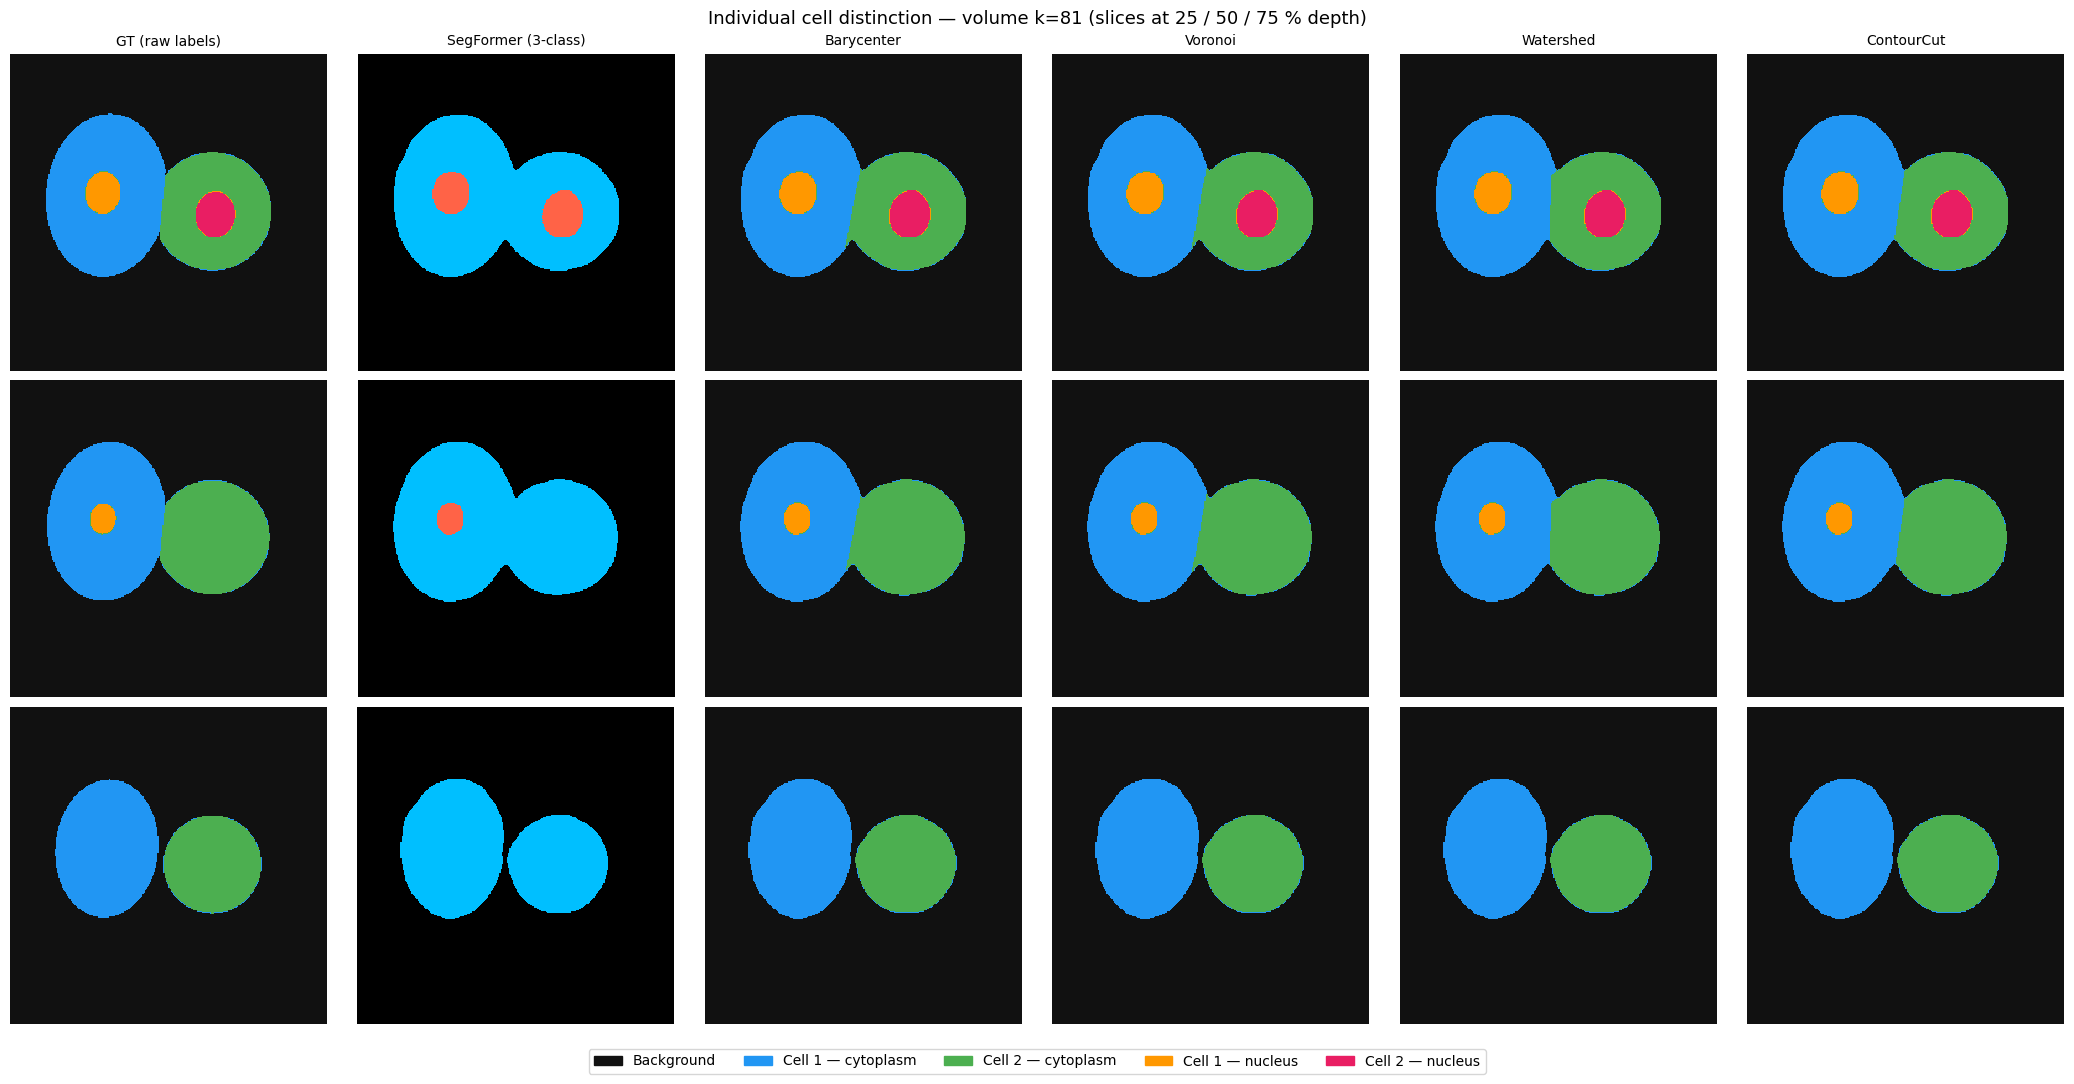

In [32]:
# ── 7. Visual comparison — one volume, 3 depth positions ─────────────────────
CMAP5 = mcolors.ListedColormap(['#111111', '#2196F3', '#4CAF50', '#FF9800', '#E91E63'])
# 0=bg, 1=cell1-cyto(blue), 2=cell2-cyto(green), 3=cell1-nuc(orange), 4=cell2-nuc(pink)
norm5 = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], CMAP5.N)
CMAP3 = mcolors.ListedColormap(['black', 'deepskyblue', 'tomato'])
norm3 = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], CMAP3.N)

k_vis    = VAL_K[-1]
res_vis  = VOLUME_RESULTS[k_vis]
gt_4c_v  = res_vis['gt_4c']
pred_3c  = res_vis['pred_3c']
n_sl     = gt_4c_v.shape[0]

# Show three representative slices
slice_idx  = [n_sl // 4, n_sl // 2, 3 * n_sl // 4]
col_titles = ['GT (raw labels)', 'SegFormer (3-class)'] + list(METHODS)
n_rows, n_cols = len(slice_idx), len(col_titles)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.5 * n_cols, 3.5 * n_rows))

for row, s in enumerate(slice_idx):
    axes[row, 0].imshow(gt_4c_v[s],  cmap=CMAP5, norm=norm5)
    axes[row, 0].set_ylabel(f'slice {s}', fontsize=10)
    axes[row, 1].imshow(pred_3c[s],  cmap=CMAP3, norm=norm3)
    for col, mname in enumerate(METHODS, start=2):
        pred_4c = res_vis.get(mname)
        if pred_4c is None:
            axes[row, col].text(0.5, 0.5, 'N/A (skipped)',
                                ha='center', va='center',
                                transform=axes[row, col].transAxes, fontsize=11)
        else:
            axes[row, col].imshow(pred_4c[s], cmap=CMAP5, norm=norm5)
    for ax in axes[row]:
        ax.axis('off')

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10)

patches = [
    mpatches.Patch(color='#111111', label='Background'),
    mpatches.Patch(color='#2196F3', label='Cell 1 — cytoplasm'),
    mpatches.Patch(color='#4CAF50', label='Cell 2 — cytoplasm'),
    mpatches.Patch(color='#FF9800', label='Cell 1 — nucleus'),
    mpatches.Patch(color='#E91E63', label='Cell 2 — nucleus'),
]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle(f'Individual cell distinction — volume k={k_vis} '
             f'(slices at 25 / 50 / 75 % depth)', fontsize=13)
plt.tight_layout()
plt.show()

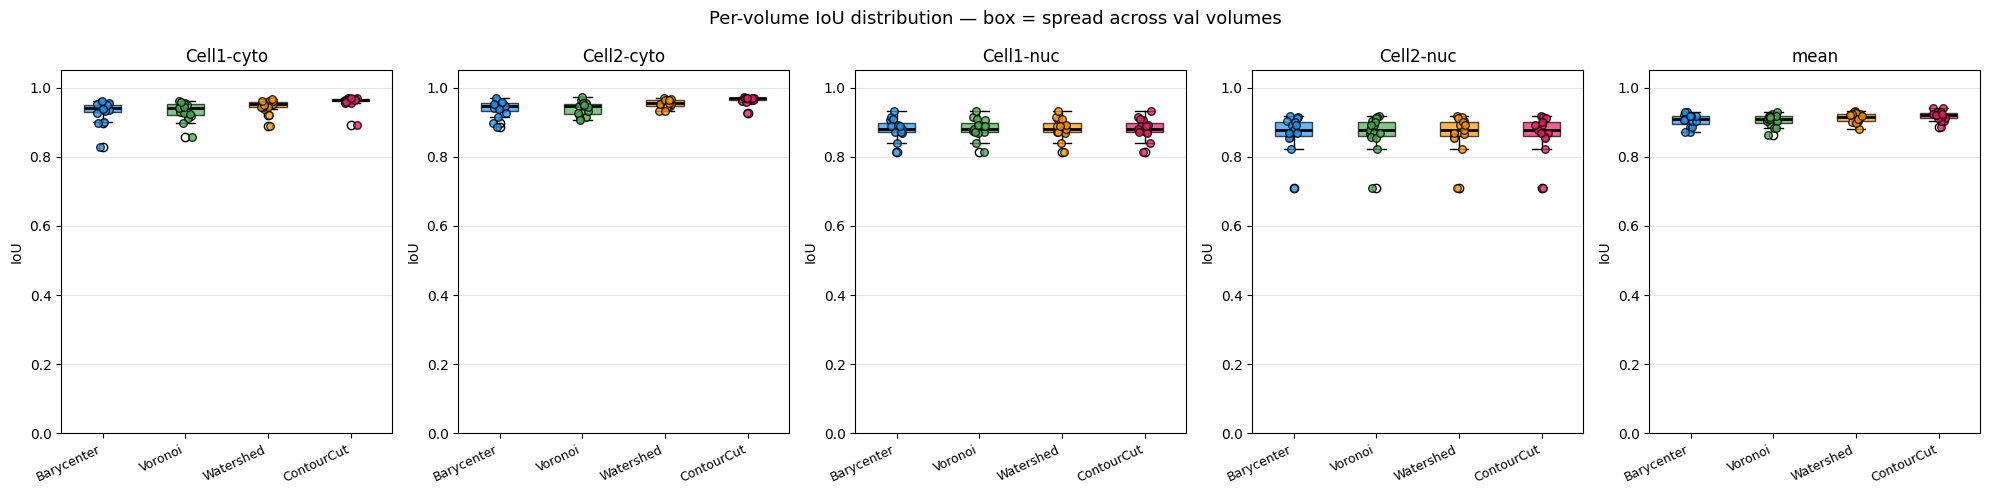

In [28]:
# ── 8. Per-volume IoU box-plots (consistency across volumes) ──────────────────
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(4 * len(CLASS_NAMES), 5))

for ax, cn in zip(axes, CLASS_NAMES):
    data_box   = [
        [v[cn]['IoU'] for v in METHOD_METRICS[m] if cn in v]
        for m in METHODS if METHOD_METRICS[m]
    ]
    valid_names  = [m for m in METHODS if METHOD_METRICS[m]]
    colors_box   = [METHOD_COLORS.get(m, 'grey') for m in valid_names]

    bp = ax.boxplot(data_box, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    for i, (d, c) in enumerate(zip(data_box, colors_box), start=1):
        ax.scatter(np.full(len(d), i) + np.random.uniform(-0.08, 0.08, len(d)),
                   d, color=c, edgecolors='k', s=30, zorder=5, alpha=0.8)

    ax.set_xticks(range(1, len(valid_names) + 1))
    ax.set_xticklabels(valid_names, rotation=25, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_ylabel('IoU')
    ax.set_title(cn); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Per-volume IoU distribution — box = spread across val volumes',
             fontsize=13)
plt.tight_layout()
plt.show()

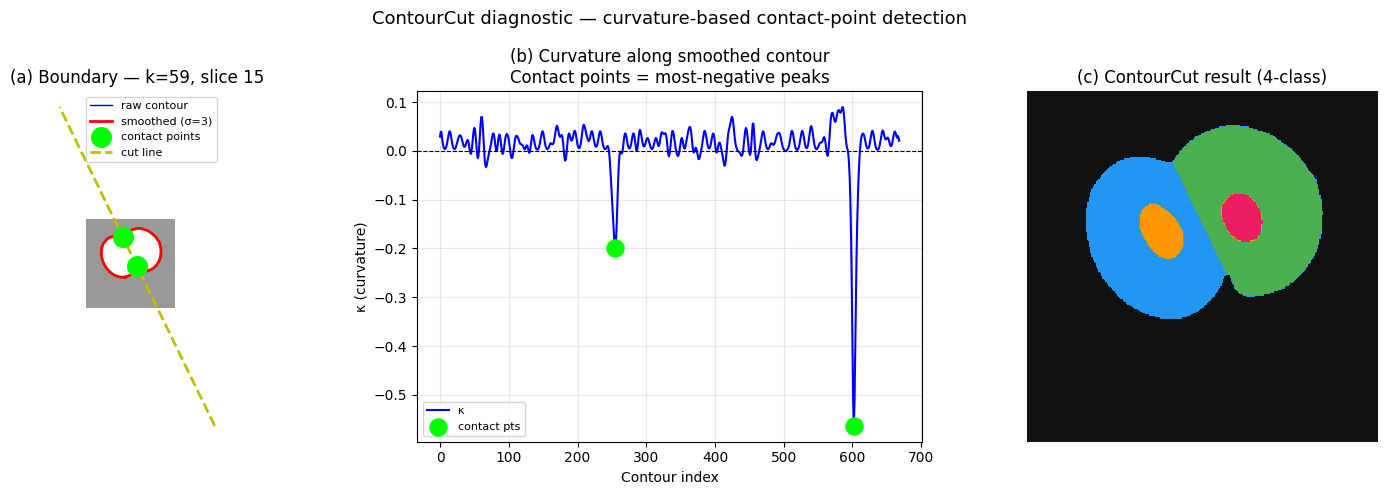

Touching slice found: 15  |  contour length: 669 pts  |  contact points found: True


In [22]:
# ── 10. ContourCut diagnostic: curvature analysis on one slice ────────────────
# Pick a slice where cells are visibly touching (one combined 2-D CC).
# Shows: combined boundary | smoothed contour | κ curve | contact points | cut line.

k_diag   = VAL_K[0]
res_diag = VOLUME_RESULTS[k_diag]
pred_3c  = res_diag['pred_3c']
gt_4c_d  = res_diag['gt_4c']

# Find a slice with one big connected component (cells touching)
n_sl = pred_3c.shape[0]
touching_slice = None
for s in range(n_sl // 4, 3 * n_sl // 4):
    combined = (pred_3c[s] > 0)
    _, nc = nd_label(combined)
    if nc == 1 and combined.sum() > 500:
        touching_slice = s
        break

if touching_slice is None:
    print('No touching slice found in this volume — cells may always be separate.')
else:
    s        = touching_slice
    combined = (pred_3c[s] > 0)
    cyto_s   = (pred_3c[s] == 1)

    # Run the curvature analysis
    contours = skimage_find_contours(combined.astype(float), 0.5)
    contour  = max(contours, key=len)
    n        = len(contour)
    y_sm     = gaussian_filter1d(contour[:, 0], sigma=3, mode='wrap')
    x_sm     = gaussian_filter1d(contour[:, 1], sigma=3, mode='wrap')
    dy, dx   = np.gradient(y_sm), np.gradient(x_sm)
    d2y, d2x = np.gradient(dy), np.gradient(dx)
    kappa    = (dx * d2y - dy * d2x) / (dx**2 + dy**2 + 1e-8)**1.5

    pts = find_contact_points_2d(combined)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── (a) Combined mask + raw contour ──────────────────────────────────────
    ax = axes[0]
    ax.imshow(combined, cmap='gray', alpha=0.4)
    ax.plot(contour[:, 1], contour[:, 0], 'b-', lw=1, label='raw contour')
    ax.plot(x_sm, y_sm, 'r-', lw=2, label='smoothed (σ=3)')
    if pts is not None:
        p1, p2 = pts
        ax.scatter([p1[1], p2[1]], [p1[0], p2[0]],
                   s=200, c='lime', zorder=5, label='contact points')
        # Draw the cut line (extended across the image)
        dr, dc = p2[0] - p1[0], p2[1] - p1[1]
        length = max(combined.shape) * 2
        norm   = np.hypot(dr, dc) + 1e-8
        ax.plot([p1[1] - dc/norm*length, p1[1] + dc/norm*length],
                [p1[0] - dr/norm*length, p1[0] + dr/norm*length],
                'y--', lw=2, label='cut line')
    ax.set_title(f'(a) Boundary — k={k_diag}, slice {s}')
    ax.legend(fontsize=8); ax.axis('off')

    # ── (b) Curvature κ along the contour ────────────────────────────────────
    ax = axes[1]
    t  = np.arange(n)
    ax.plot(t, kappa, 'b-', lw=1.5, label='κ')
    ax.axhline(0, color='k', lw=0.8, linestyle='--')
    if pts is not None:
        # Identify the contour indices of the contact points
        min_dist = max(int(n * 0.2), 5)
        neg_peaks, _ = sp_find_peaks(-kappa, distance=min_dist)
        if len(neg_peaks) >= 2:
            order = np.argsort(kappa[neg_peaks])
            top2  = neg_peaks[order[:2]]
            ax.scatter(top2, kappa[top2], s=150, c='lime', zorder=5,
                       label='contact pts')
    ax.set_xlabel('Contour index'); ax.set_ylabel('κ (curvature)')
    ax.set_title('(b) Curvature along smoothed contour\n'
                 'Contact points = most-negative peaks')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── (c) Resulting cut ─────────────────────────────────────────────────────
    ax = axes[2]
    pred_4c_d = res_diag.get('ContourCut')
    if pred_4c_d is not None:
        CMAP5 = mcolors.ListedColormap(['#111111', '#2196F3', '#4CAF50',
                                        '#FF9800', '#E91E63'])
        norm5 = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], CMAP5.N)
        ax.imshow(pred_4c_d[s], cmap=CMAP5, norm=norm5)
        ax.set_title('(c) ContourCut result (4-class)')
    else:
        ax.text(0.5, 0.5, 'ContourCut not run yet\n(run cell-run first)',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_title('(c) ContourCut result')
    ax.axis('off')

    plt.suptitle('ContourCut diagnostic — curvature-based contact-point detection',
                 fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f'Touching slice found: {s}  |  contour length: {n} pts  |  '
          f'contact points found: {pts is not None}')


---
## Interpretation guide

| Metric pattern | Likely cause |
|---|---|
| All methods ≈ Oracle | Nucleus segmentation is the bottleneck; post-processing strategy barely matters |
| Nucleus IoU high, cytoplasm IoU low | Nuclei found correctly but cytoplasm boundary between cells is hard to split |
| Large gap between Oracle and other methods | Nucleus CCs found by SegFormer are noisy / fragmented; better nucleus seg needed |
| Barycenter ≈ Voronoi ≈ Watershed | Nuclei are compact and well-separated — simpler method is sufficient |
| Voronoi > Barycenter | Nuclei are elongated or non-spherical |
| Watershed ≠ Voronoi | Cell region has concave boundaries where watershed follows topology |

**Key numbers to look at:**
- `mean` column in the metrics table — overall cell-distinction accuracy
- `Cell1-nuc` / `Cell2-nuc` — nucleus assignment quality (drives everything else)
- `Oracle mean` − `best-method mean` — room for improvement via better nucleus segmentation